In [1]:
#Імпорт бібліотек
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
#Зчитування даних
data = pd.read_csv("healthcare_dataset.csv")

#Створення бінарної цільової змінної: 1 якщо Test Results == "Normal", 0 інакше
data["Test_Result_Normal"] = (data["Test Results"] == "Normal").astype(int)

#Чистка датасету від непотрібних колонок
cols_to_drop = ["Name", "Date of Admission", "Doctor", "Hospital",
                "Room Number", "Discharge Date", "Test Results"]
data = data.drop(columns=cols_to_drop)

#One-hot encoding для категоріальних змінних
categorical_cols = ["Gender", "Blood Type", "Medical Condition",
"Insurance Provider", "Admission Type", "Medication"]
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

#Нормалізація числових змінних
for col in ["Age", "Billing Amount"]:
    data[col] = (data[col] - data[col].mean()) / data[col].std()

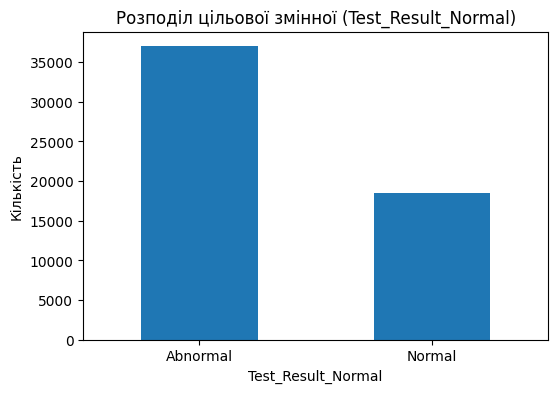

In [3]:
   #Розподіл цільової змінної
plt.figure(figsize=(6,4))
data["Test_Result_Normal"].value_counts().plot(kind="bar")
plt.title("Розподіл цільової змінної (Test_Result_Normal)")
plt.xticks([0,1],["Abnormal","Normal"], rotation=0)
plt.ylabel("Кількість")
plt.show()

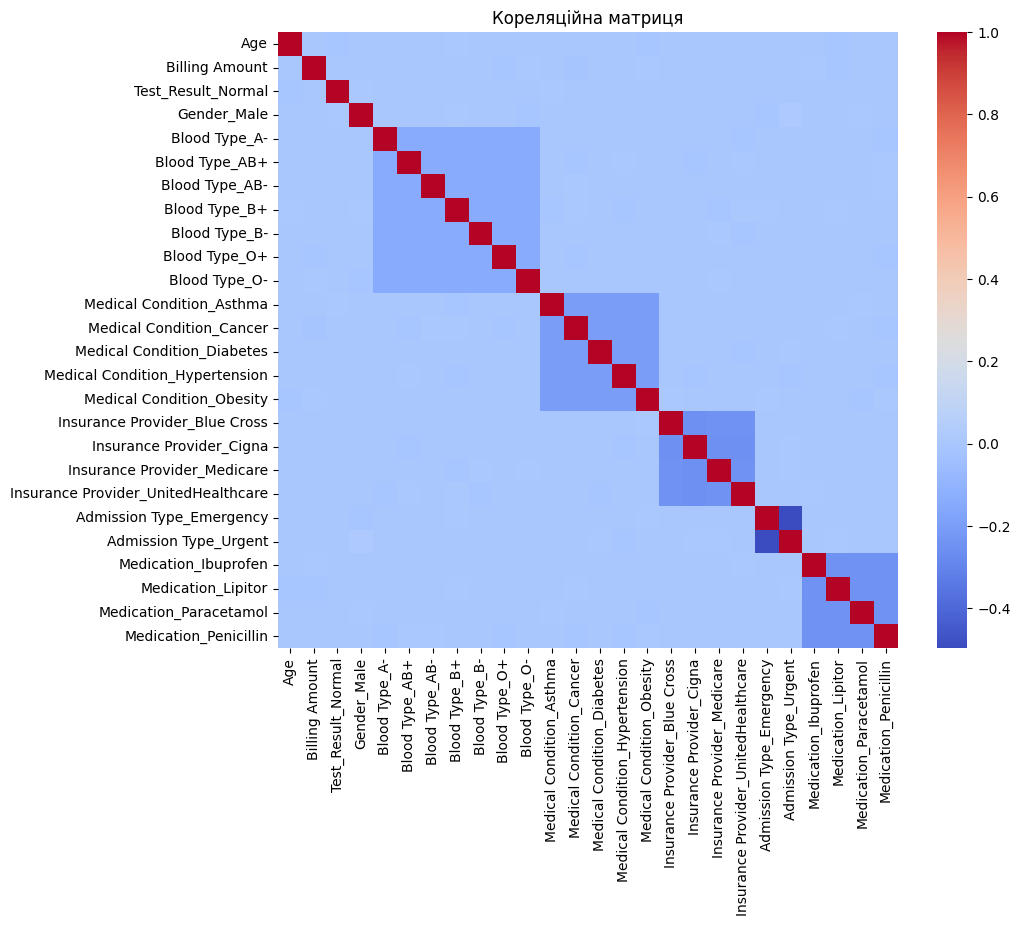

In [4]:
#Кореляційна матриця числових ознак
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=False, cmap="coolwarm")
plt.title("Кореляційна матриця")
plt.show()

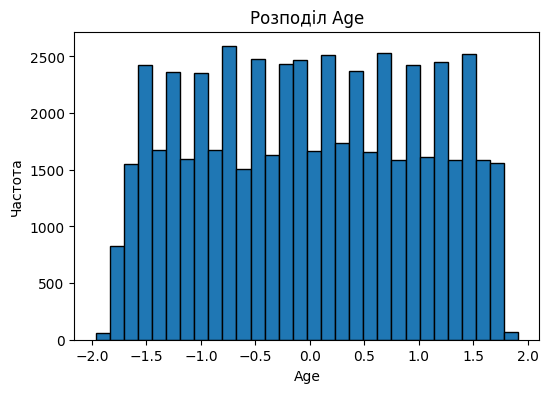

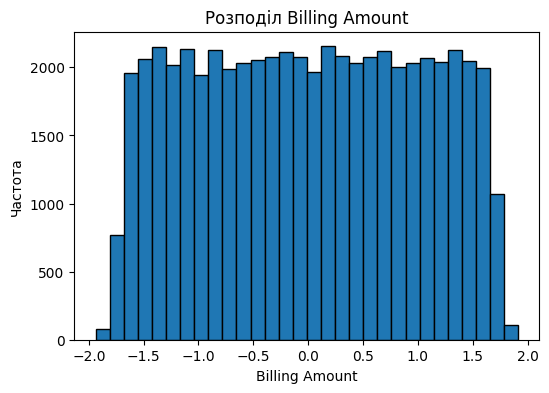

In [5]:
#Гістограми для числових ознак
num_cols = ["Age", "Billing Amount"]
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(data[col], bins=30, edgecolor="black")
    plt.title(f"Розподіл {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show() 

In [5]:
#Ознаки та цільова змінна
X = data.drop("Test_Result_Normal", axis=1).astype(float).values
y = data["Test_Result_Normal"].astype(float).values.reshape(-1, 1)

#Колонка з 1 для інтерсепта
X = np.hstack([np.ones((X.shape[0], 1)), X])

#Розділ на train (60%), val (20%), test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [6]:
def sigmoid(z):
    """Сигмоїдальна функція."""
    return 1 / (1 + np.exp(-z))

def predict_proba(X, weights):
    """Ймовірності належності до класу 1."""
    return sigmoid(np.dot(X, weights))

def compute_loss(X, y, weights, reg_type=None, reg_lambda=0.0):
    """Log Loss з опціональною L1/L2 регуляризацією."""
    m = len(y)
    h = predict_proba(X, weights)
    epsilon = 1e-15 #для уникнення log(0)
    loss = - (1/m) * (np.dot(y.T, np.log(h + epsilon)) + np.dot((1-y).T, np.log(1-h + epsilon)))
    #Додаємо регуляризацію (не для w0)
    if reg_type == "l2":
        loss += (reg_lambda / (2*m)) * np.sum(weights[1:]**2)
    elif reg_type == "l1":
        loss += (reg_lambda / m) * np.sum(np.abs(weights[1:]))
    return loss.flatten()[0]

def compute_gradient(X, y, weights, reg_type=None, reg_lambda=0.0):
    """Градієнт функції втрат."""
    m = len(y)
    h = predict_proba(X, weights)
    gradient = (1/m) * np.dot(X.T, (h - y))
    #Регуляризація (не для w0)
    if reg_type == "l2":
        gradient[1:] += (reg_lambda/m) * weights[1:]
    elif reg_type == "l1":
        gradient[1:] += (reg_lambda/m) * np.sign(weights[1:])
    return gradient

In [7]:
def get_batches(X, y, batch_size):
    for i in range(0, len(y), batch_size):
        yield X[i:i+batch_size], y[i:i+batch_size]

def train_logistic_regression(X_train, y_train, X_val, y_val, lr=0.01, epochs=100,
                              batch_size=1, reg_type=None, reg_lambda=0.0, patience=10):
    n_features = X_train.shape[1]
    weights = np.zeros((n_features, 1))

    best_weights = None
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        #Перемішуємо дані перед епохою
        indices = np.arange(len(y_train))
        np.random.shuffle(indices)
        X_train, y_train = X_train[indices], y_train[indices]
    
        #Навчання (SGD якщо batch_size=1, Mini-batch якщо batch_size>1)
        for X_batch, y_batch in get_batches(X_train, y_train, batch_size):
            grad = compute_gradient(X_batch, y_batch, weights, reg_type, reg_lambda)
            weights -= lr * grad

        #Підрахунок втрат
        train_loss = compute_loss(X_train, y_train, weights, reg_type, reg_lambda)
        val_loss = compute_loss(X_val, y_val, weights, reg_type, reg_lambda)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        #Рання зупинка
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = weights.copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    return best_weights, train_losses, val_losses

In [8]:
#Стохастичний GD (batch_size=1)
weights_sgd, train_losses_sgd, val_losses_sgd = train_logistic_regression(X_train, y_train, X_val, y_val, lr=0.01, epochs=2000, batch_size=1)

#Mini-batch GD (batch_size=32)
weights_mbgd, train_losses_mbgd, val_losses_mbgd = train_logistic_regression(X_train, y_train, X_val, y_val, lr=0.01, epochs=2000, batch_size=32)

Early stopping at epoch 40
Early stopping at epoch 64


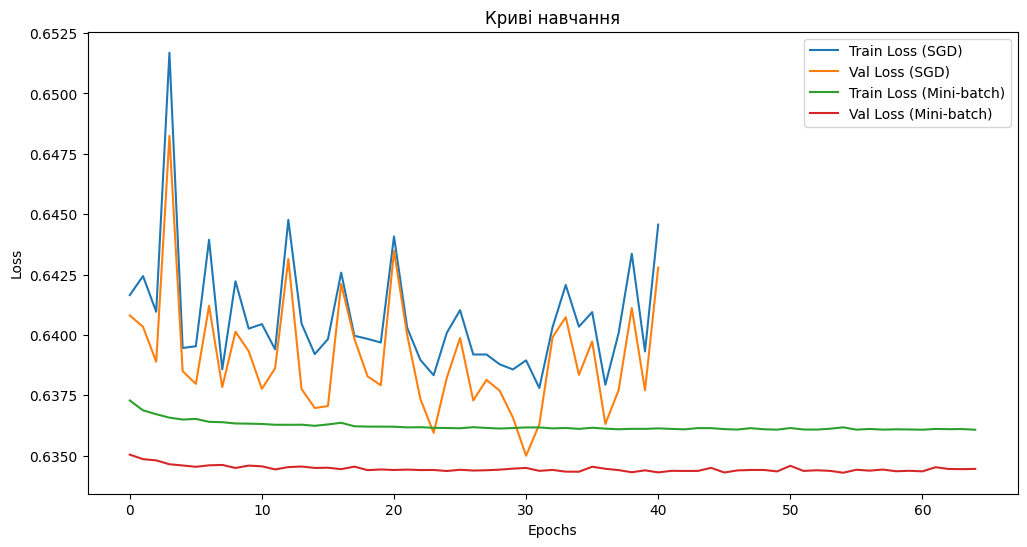

In [9]:
#Візуалізація кривих навчання
plt.figure(figsize=(12,6))
plt.plot(train_losses_sgd, label="Train Loss (SGD)")
plt.plot(val_losses_sgd, label="Val Loss (SGD)")
plt.plot(train_losses_mbgd, label="Train Loss (Mini-batch)")
plt.plot(val_losses_mbgd, label="Val Loss (Mini-batch)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Криві навчання")
plt.legend()
plt.show()

In [12]:
#Оцінка моделі на тесті

def evaluate_model(X_test, y_test, weights):
    """Обчислення метрик якості."""
    y_pred_proba = predict_proba(X_test, weights)
    y_pred = (y_pred_proba >= 0.3).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    return cm, acc, prec, rec, f1

#Оцінка SGD
cm_sgd, acc_sgd, prec_sgd, rec_sgd, f1_sgd = evaluate_model(X_test, y_test, weights_sgd)

#Оцінка Mini-batch
cm_mbgd, acc_mbgd, prec_mbgd, rec_mbgd, f1_mbgd = evaluate_model(X_test, y_test, weights_mbgd)

print("=== Результати SGD ===")
print("Confusion Matrix:\n", cm_sgd)
print(f"Accuracy: {acc_sgd:.4f}, Precision: {prec_sgd:.4f}, Recall: {rec_sgd:.4f}, F1: {f1_sgd:.4f}")

print("\n=== Результати Mini-batch ===")
print("Confusion Matrix:\n", cm_mbgd)
print(f"Accuracy: {acc_mbgd:.4f}, Precision: {prec_mbgd:.4f}, Recall: {rec_mbgd:.4f}, F1: {f1_mbgd:.4f}")

=== Результати SGD ===
Confusion Matrix:
 [[2048 5293]
 [1087 2672]]
Accuracy: 0.4252, Precision: 0.3355, Recall: 0.7108, F1: 0.4558

=== Результати Mini-batch ===
Confusion Matrix:
 [[  25 7316]
 [  17 3742]]
Accuracy: 0.3394, Precision: 0.3384, Recall: 0.9955, F1: 0.5051


In [ ]:
#Висновок: У ході експериментів були порівняні два методи оптимізації: стохастичний градієнтний спуск (SGD) та mini-batch.
#SGD показує швидшу реакцію на кожен приклад, однак крива навчання вийшла більш нестабільною. Незважаючи на коливання,
#модель у підсумку досягає прийнятних результатів.
#Mini-batch дає більш стабільну динаміку зменшення функції втрат. Криві навчання є більш гладкими, що свідчить про стійкіший процес оптимізації.
#Врахування дисбалансу класів (через ваги у функції втрат) суттєво підвищило здатність моделі виявляти рідкісний клас «Normal». 
#Без цього модель схилялася до передбачення лише класу «Abnormal».
#Підбір порогу класифікації (наприклад, 0.3 замість стандартного 0.5) дозволив досягти кращого балансу між Precision та Recall, підвищивши F1-метрику.
#Отже, обидва методи (SGD та mini-batch) є ефективними, але mini-batch продемонстрував більш стабільну збіжність. 
#Для задачі з дисбалансом класів критично важливим виявилося використання ваг у функції втрат та оптимального порогу класифікації.